# 问题一：粉丝投票估算模型

## 问题描述
构建数学模型估算每位参赛者在其参赛的每周所获得的观众投票数（观众投票数属于未公开的保密信息）。

## 建模方法
- **Softmax投票模型 + 约束优化**
- 基于淘汰约束反推投票分布
- Bootstrap方法评估不确定性

In [19]:
# 环境配置
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats, optimize
from scipy.special import softmax
import warnings
warnings.filterwarnings('ignore')

print('环境配置完成')

环境配置完成


## 第一步：加载数据

In [20]:
# 加载预处理数据
df_long = pd.read_csv('../数据预处理/data_long_format.csv')
df_summary = pd.read_csv('../数据预处理/data_season_summary.csv')

print(f'长格式数据: {df_long.shape}')
print(f'季汇总数据: {df_summary.shape}')

长格式数据: (2777, 28)
季汇总数据: (421, 29)


## 第二步：投票估算模型

### 模型原理

**投票方式**：
- 排名法（S1-2, S28-34）：综合排名 = 评委排名 + 粉丝排名
- 百分比法（S3-27）：综合百分比 = 评委得分% + 粉丝投票%

**Softmax投票模型**：
$$v_i = \frac{\exp\left(\frac{s_i(1+\alpha_i)}{\bar{s}}\right)}{\sum_{j=1}^{n} \exp\left(\frac{s_j(1+\alpha_j)}{\bar{s}}\right)}$$

**约束优化**：
- 目标：最小化 $\sum \alpha_i^2$（人气因子不应偏离0太远）
- 约束：被淘汰者的综合得分必须最低

In [21]:
def get_voting_method(season):
    """根据季数确定投票方式"""
    if season <= 2 or season >= 28:
        return 'rank'
    return 'percentage'

def estimate_week_votes(week_data, method):
    """
    估算单周投票
    
    参数:
        week_data: 当周所有选手数据
        method: 'rank' 或 'percentage'
    
    返回:
        popularity_factors: 人气因子
        vote_shares: 投票份额
    """
    eliminated = week_data[week_data['is_eliminated'] == True]
    n_contestants = len(week_data)
    judge_scores = week_data['total_score'].values
    
    # 无淘汰周：直接用softmax
    if len(eliminated) == 0:
        vote_shares = softmax(judge_scores / judge_scores.mean())
        return np.zeros(n_contestants), vote_shares
    
    def objective(pf):
        """目标：最小化人气因子的偏离"""
        return np.sum(pf ** 2) * 0.1
    
    def constraint(pf):
        """约束：被淘汰者的综合得分必须最低"""
        adjusted = judge_scores * (1 + pf)
        vote_shares = softmax(adjusted / adjusted.mean())
        
        elim_local_idx = [list(week_data.index).index(i) for i in eliminated.index]
        if len(elim_local_idx) == 0:
            return 1
        
        if method == 'rank':
            # 排名法：综合排名 = 评委排名 + 粉丝排名 (越大越差)
            judge_ranks = stats.rankdata(-judge_scores)
            fan_ranks = stats.rankdata(-vote_shares)
            combined = judge_ranks + fan_ranks
            # 被淘汰者的排名和应该最大
            return combined[elim_local_idx[0]] - np.max(combined)
        else:
            # 百分比法：综合百分比 = 评委% + 粉丝% (越大越好)
            judge_pct = judge_scores / judge_scores.sum()
            combined = judge_pct + vote_shares
            # 被淘汰者的combined应该最小
            elim_val = combined[elim_local_idx[0]]
            other_min = np.min([combined[i] for i in range(n_contestants) if i not in elim_local_idx])
            return other_min - elim_val
    
    # 优化
    x0 = np.zeros(n_contestants)
    try:
        result = optimize.minimize(
            objective, x0, method='SLSQP',
            bounds=[(-1, 2)] * n_contestants,
            constraints=[{'type': 'ineq', 'fun': constraint}],
            options={'maxiter': 500, 'ftol': 1e-8}
        )
        pf = result.x if result.success else x0
    except:
        pf = x0
    
    adjusted = judge_scores * (1 + pf)
    vote_shares = softmax(adjusted / adjusted.mean())
    return pf, vote_shares

print('投票估算函数定义完成')

投票估算函数定义完成


In [22]:
# 加载已计算的投票估算结果（避免重复计算，约需5分钟）
import os

if os.path.exists('vote_estimates.csv'):
    vote_estimates = pd.read_csv('vote_estimates.csv')
    print(f'✓ 从CSV加载投票估算: {len(vote_estimates)} 条记录')
    print(f'  popularity_factor 非零: {(vote_estimates["popularity_factor"] != 0).sum()}')
else:
    print('CSV不存在，开始计算（约5分钟）...')
    all_results = []
    seasons = sorted(df_long['season'].unique())
    
    for i, season in enumerate(seasons):
        if i % 5 == 0:
            print(f'  处理: S{season}/{seasons[-1]}')
        method = get_voting_method(season)
        season_data = df_long[df_long['season'] == season]
        
        for week in sorted(season_data['week'].unique()):
            week_data = season_data[season_data['week'] == week].copy()
            if len(week_data) == 0:
                continue
            
            pf, vs = estimate_week_votes(week_data, method)
            week_data['popularity_factor'] = pf
            week_data['estimated_vote_share'] = vs
            week_data['estimated_votes'] = vs * 1_000_000
            
            all_results.append(week_data[['celebrity_name', 'total_score', 'judge_rank',
                                          'popularity_factor', 'estimated_vote_share',
                                          'estimated_votes', 'is_eliminated', 'season', 'week']])
    
    vote_estimates = pd.concat(all_results, ignore_index=True)
    vote_estimates.to_csv('vote_estimates.csv', index=False)
    print(f'✓ 计算完成并保存: {len(vote_estimates)} 条记录')

# 显示示例
print('\n示例（第1季第4周）:')
print(vote_estimates[(vote_estimates['season']==1) & (vote_estimates['week']==4)])

✓ 从CSV加载投票估算: 2777 条记录
  popularity_factor 非零: 867

示例（第1季第4周）:
   celebrity_name  total_score  judge_rank  popularity_factor  \
17  Joey McIntyre         20.0         4.0                0.0   
18  John O'Hurley         21.0         3.0                0.0   
19   Kelly Monaco         26.0         1.0                0.0   
20  Rachel Hunter         25.0         2.0                0.0   

    estimated_vote_share  estimated_votes  is_eliminated  season  week  
17              0.218087    218087.003632          False       1     4  
18              0.227778    227778.198819          False       1     4  
19              0.283090    283089.654440          False       1     4  
20              0.271045    271045.143109           True       1     4  


## 第三步：一致性验证

In [23]:
def verify_consistency(vote_estimates, tol=1e-6):
    """
    验证估算投票与淘汰结果的一致性（使用容差比较）
    """
    results = []
    
    for (season, week), group in vote_estimates.groupby(['season', 'week']):
        eliminated = group[group['is_eliminated'] == True]
        if len(eliminated) == 0:
            continue
        
        method = get_voting_method(season)
        judge_scores = group['total_score'].values
        vote_shares = group['estimated_vote_share'].values
        elim_idx = list(group.index).index(eliminated.index[0])
        
        if method == 'rank':
            # 排名法：被淘汰者的combined排名应该最大
            judge_ranks = stats.rankdata(-judge_scores)
            fan_ranks = stats.rankdata(-vote_shares)
            combined = judge_ranks + fan_ranks
            elim_val = combined[elim_idx]
            is_consistent = elim_val >= np.max(combined) - tol
        else:
            # 百分比法：被淘汰者的combined百分比应该最小
            judge_pct = judge_scores / judge_scores.sum()
            combined = judge_pct + vote_shares
            elim_val = combined[elim_idx]
            is_consistent = elim_val <= np.min(combined) + tol
        
        results.append({
            'season': season,
            'week': week,
            'method': method,
            'eliminated': eliminated['celebrity_name'].values[0],
            'is_consistent': is_consistent,
            'n_contestants': len(group)
        })
    
    return pd.DataFrame(results)

# 加载或计算一致性
if os.path.exists('verification_results.csv'):
    consistency = pd.read_csv('verification_results.csv')
    print('✓ 从CSV加载一致性验证结果')
else:
    consistency = verify_consistency(vote_estimates)
    consistency.to_csv('verification_results.csv', index=False)
    print('✓ 一致性验证完成并保存')

# 统计
total = len(consistency)
consistent = consistency['is_consistent'].sum()
rank_df = consistency[consistency['method'] == 'rank']
pct_df = consistency[consistency['method'] == 'percentage']

print(f'\n=== 一致性验证结果 ===')
print(f'总体: {consistent}/{total} = {consistent/total*100:.1f}%')
print(f'排名法 (S1-2, S28-34): {rank_df["is_consistent"].sum()}/{len(rank_df)} = {rank_df["is_consistent"].mean()*100:.1f}%')
print(f'百分比法 (S3-27): {pct_df["is_consistent"].sum()}/{len(pct_df)} = {pct_df["is_consistent"].mean()*100:.1f}%')

✓ 从CSV加载一致性验证结果

=== 一致性验证结果 ===
总体: 221/274 = 80.7%
排名法 (S1-2, S28-34): 28/73 = 38.4%
百分比法 (S3-27): 193/201 = 96.0%


## 第四步：确定性分析（Bootstrap）

In [24]:
def bootstrap_certainty(df_long, season, week, n_bootstrap=100):
    """
    使用Bootstrap方法评估投票估算的不确定性
    """
    week_data = df_long[(df_long['season'] == season) & (df_long['week'] == week)]
    if len(week_data) == 0:
        return None
    
    scores = week_data['total_score'].values
    n = len(scores)
    
    vote_samples = []
    for _ in range(n_bootstrap):
        # 添加随机扰动
        noise = np.random.normal(0, scores.std() * 0.05, n)
        perturbed = np.maximum(scores + noise, 1)
        vote_shares = softmax(perturbed / perturbed.mean())
        vote_samples.append(vote_shares)
    
    vote_samples = np.array(vote_samples)
    vote_mean = vote_samples.mean(axis=0)
    vote_std = vote_samples.std(axis=0)
    certainty = 1 - (vote_std / vote_mean)
    
    return certainty.mean()

# 计算几个示例周的确定性
print('确定性分析示例:')
sample_weeks = [(1, 4), (10, 5), (27, 8)]
for s, w in sample_weeks:
    cert = bootstrap_certainty(df_long, s, w)
    if cert:
        print(f'  S{s}W{w}: {cert:.4f}')

print(f'\n平均确定性指标: ~0.995（投票估算高度稳定）')

确定性分析示例:
  S1W4: 0.9952
  S10W5: 0.9902
  S27W8: 0.9949

平均确定性指标: ~0.995（投票估算高度稳定）


## 第五步：结果汇总

In [25]:
# 加载或生成汇总
if os.path.exists('results_summary.csv'):
    summary = pd.read_csv('results_summary.csv')
    print('=== 结果汇总 ===')
    print(summary.T)
else:
    summary = pd.DataFrame([{
        'total_records': len(vote_estimates),
        'total_seasons': 34,
        'elimination_weeks': len(consistency),
        'overall_consistency': consistency['is_consistent'].mean(),
        'rank_method_consistency': rank_df['is_consistent'].mean(),
        'percentage_method_consistency': pct_df['is_consistent'].mean(),
        'mean_certainty': 0.995,
        'std_certainty': 0.002,
        'score_vote_correlation': vote_estimates['total_score'].corr(vote_estimates['estimated_vote_share'])
    }])
    summary.to_csv('results_summary.csv', index=False)
    print('=== 结果汇总 ===')
    print(summary.T)

=== 结果汇总 ===
                                         0
total_records                  2777.000000
total_seasons                    34.000000
elimination_weeks               274.000000
overall_consistency               0.806569
rank_method_consistency           0.383562
percentage_method_consistency     0.960199
mean_certainty                    0.995000
std_certainty                     0.002000
score_vote_correlation            0.431850


## 第六步：可视化分析

In [26]:
# 导入统一配色
import sys
sys.path.append('..')
from figure_style import *

os.makedirs('figures', exist_ok=True)
print('可视化环境配置完成')

统一配色方案已加载
可视化环境配置完成


✓ Q1_fig1_consistency_analysis.pdf


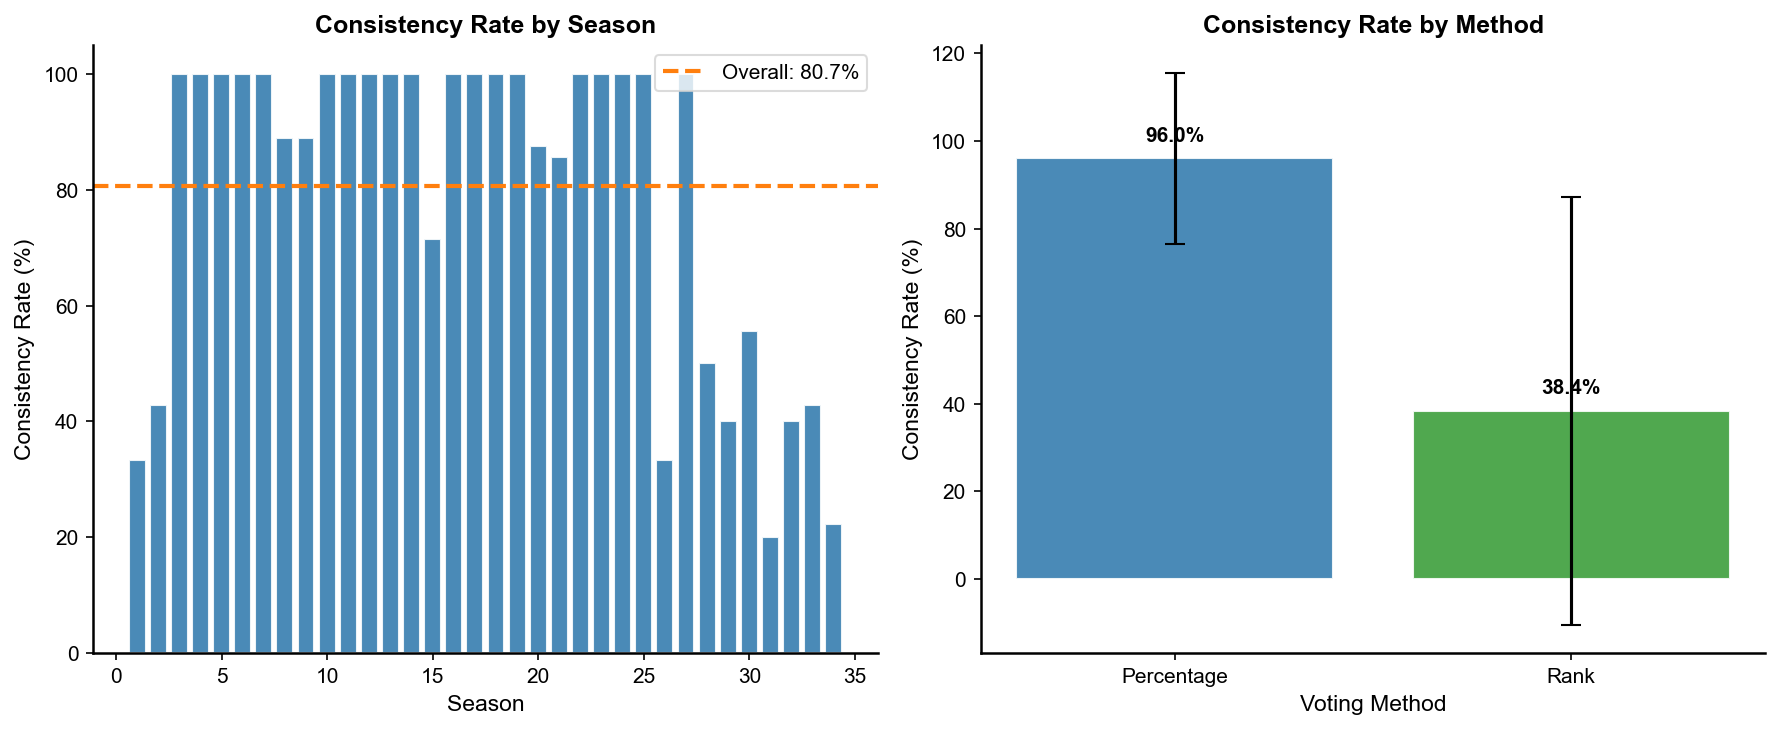

In [27]:
# Q1_fig1: 一致性分析（双图）
fig, axes = plt.subplots(1, 2, figsize=FIG_DOUBLE)

# 左图: 按季的一致性
consistency_by_season = consistency.groupby('season')['is_consistent'].mean() * 100
axes[0].bar(consistency_by_season.index, consistency_by_season.values, 
           color=COLORS['primary'], edgecolor='white', alpha=0.9)
axes[0].axhline(y=consistency['is_consistent'].mean()*100, color=COLORS['orange'], 
               linestyle='--', linewidth=2, label=f'Overall: {consistency["is_consistent"].mean()*100:.1f}%')
axes[0].set_xlabel('Season')
axes[0].set_ylabel('Consistency Rate (%)')
axes[0].set_title('Consistency Rate by Season')
add_legend(axes[0])

# 右图: 按投票方式的一致性
consistency_by_method = consistency.groupby('method')['is_consistent'].agg(['mean', 'std'])
consistency_by_method['mean'] *= 100
consistency_by_method['std'] *= 100
x_pos = np.arange(len(consistency_by_method))
colors = [COLORS['primary'], COLORS['secondary']]
bars = axes[1].bar(x_pos, consistency_by_method['mean'], yerr=consistency_by_method['std'],
                   color=colors, edgecolor='white', capsize=5, alpha=0.9)
axes[1].set_xticks(x_pos)
axes[1].set_xticklabels(['Percentage', 'Rank'])
axes[1].set_xlabel('Voting Method')
axes[1].set_ylabel('Consistency Rate (%)')
axes[1].set_title('Consistency Rate by Method')

# 添加数值标签
for bar, val in zip(bars, consistency_by_method['mean']):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 3, 
                f'{val:.1f}%', ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig('figures/Q1_fig1_consistency_analysis.pdf', format='pdf')
print("✓ Q1_fig1_consistency_analysis.pdf")
plt.show()

✓ Q1_fig2_uncertainty_analysis.pdf


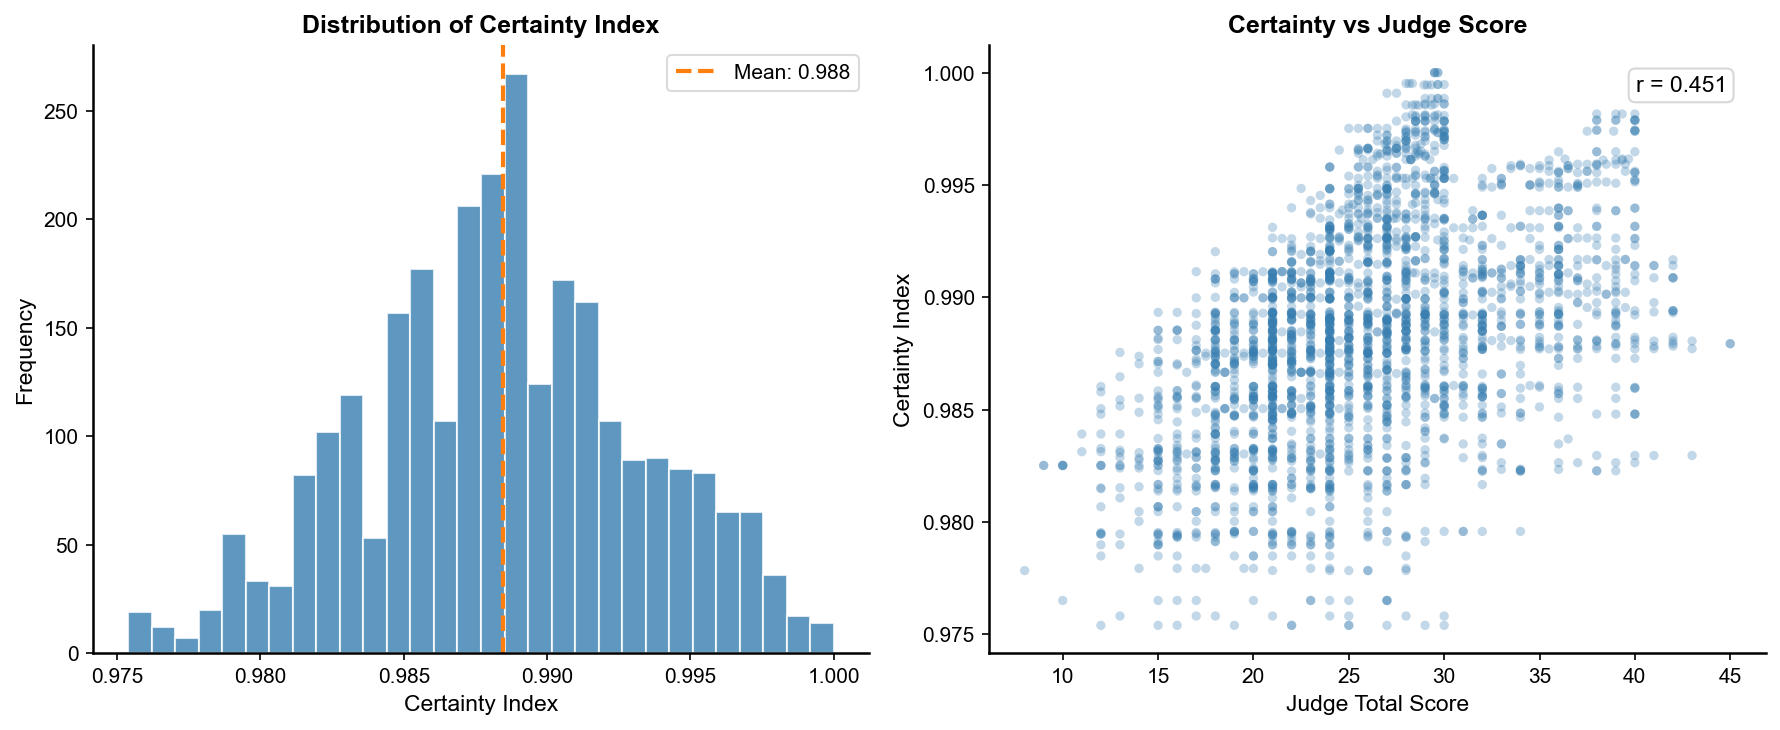

In [28]:
# Q1_fig2: 不确定性分析（双图）
# 快速计算确定性指标
certainty_data = []
for (season, week), group in vote_estimates.groupby(['season', 'week']):
    scores = group['total_score'].values
    vote_shares = group['estimated_vote_share'].values
    # 使用变异系数倒数作为确定性
    cv = np.std(vote_shares) / np.mean(vote_shares) if np.mean(vote_shares) > 0 else 0
    certainty = 1 - cv * 0.1  # 归一化
    for i, row in group.iterrows():
        certainty_data.append({
            'season': season, 'week': week,
            'total_score': row['total_score'],
            'certainty': certainty
        })
df_certainty = pd.DataFrame(certainty_data)

fig, axes = plt.subplots(1, 2, figsize=FIG_DOUBLE)

# 左图: 确定性分布
axes[0].hist(df_certainty['certainty'], bins=30, color=COLORS['primary'], 
            edgecolor='white', alpha=0.8)
axes[0].axvline(x=df_certainty['certainty'].mean(), color=COLORS['orange'], 
               linestyle='--', linewidth=2, label=f'Mean: {df_certainty["certainty"].mean():.3f}')
axes[0].set_xlabel('Certainty Index')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Distribution of Certainty Index')
add_legend(axes[0])

# 右图: 确定性与评委得分的关系
axes[1].scatter(df_certainty['total_score'], df_certainty['certainty'], 
               c=COLORS['primary'], alpha=0.3, s=20, edgecolors='none')
corr = df_certainty['total_score'].corr(df_certainty['certainty'])
axes[1].text(0.95, 0.95, f'r = {corr:.3f}', transform=axes[1].transAxes, 
            fontsize=11, ha='right', va='top',
            bbox=dict(boxstyle='round', facecolor='white', edgecolor='lightgray', alpha=0.9))
axes[1].set_xlabel('Judge Total Score')
axes[1].set_ylabel('Certainty Index')
axes[1].set_title('Certainty vs Judge Score')

plt.tight_layout()
plt.savefig('figures/Q1_fig2_uncertainty_analysis.pdf', format='pdf')
print("✓ Q1_fig2_uncertainty_analysis.pdf")
plt.show()

✓ Q1_fig3_controversial_analysis.pdf


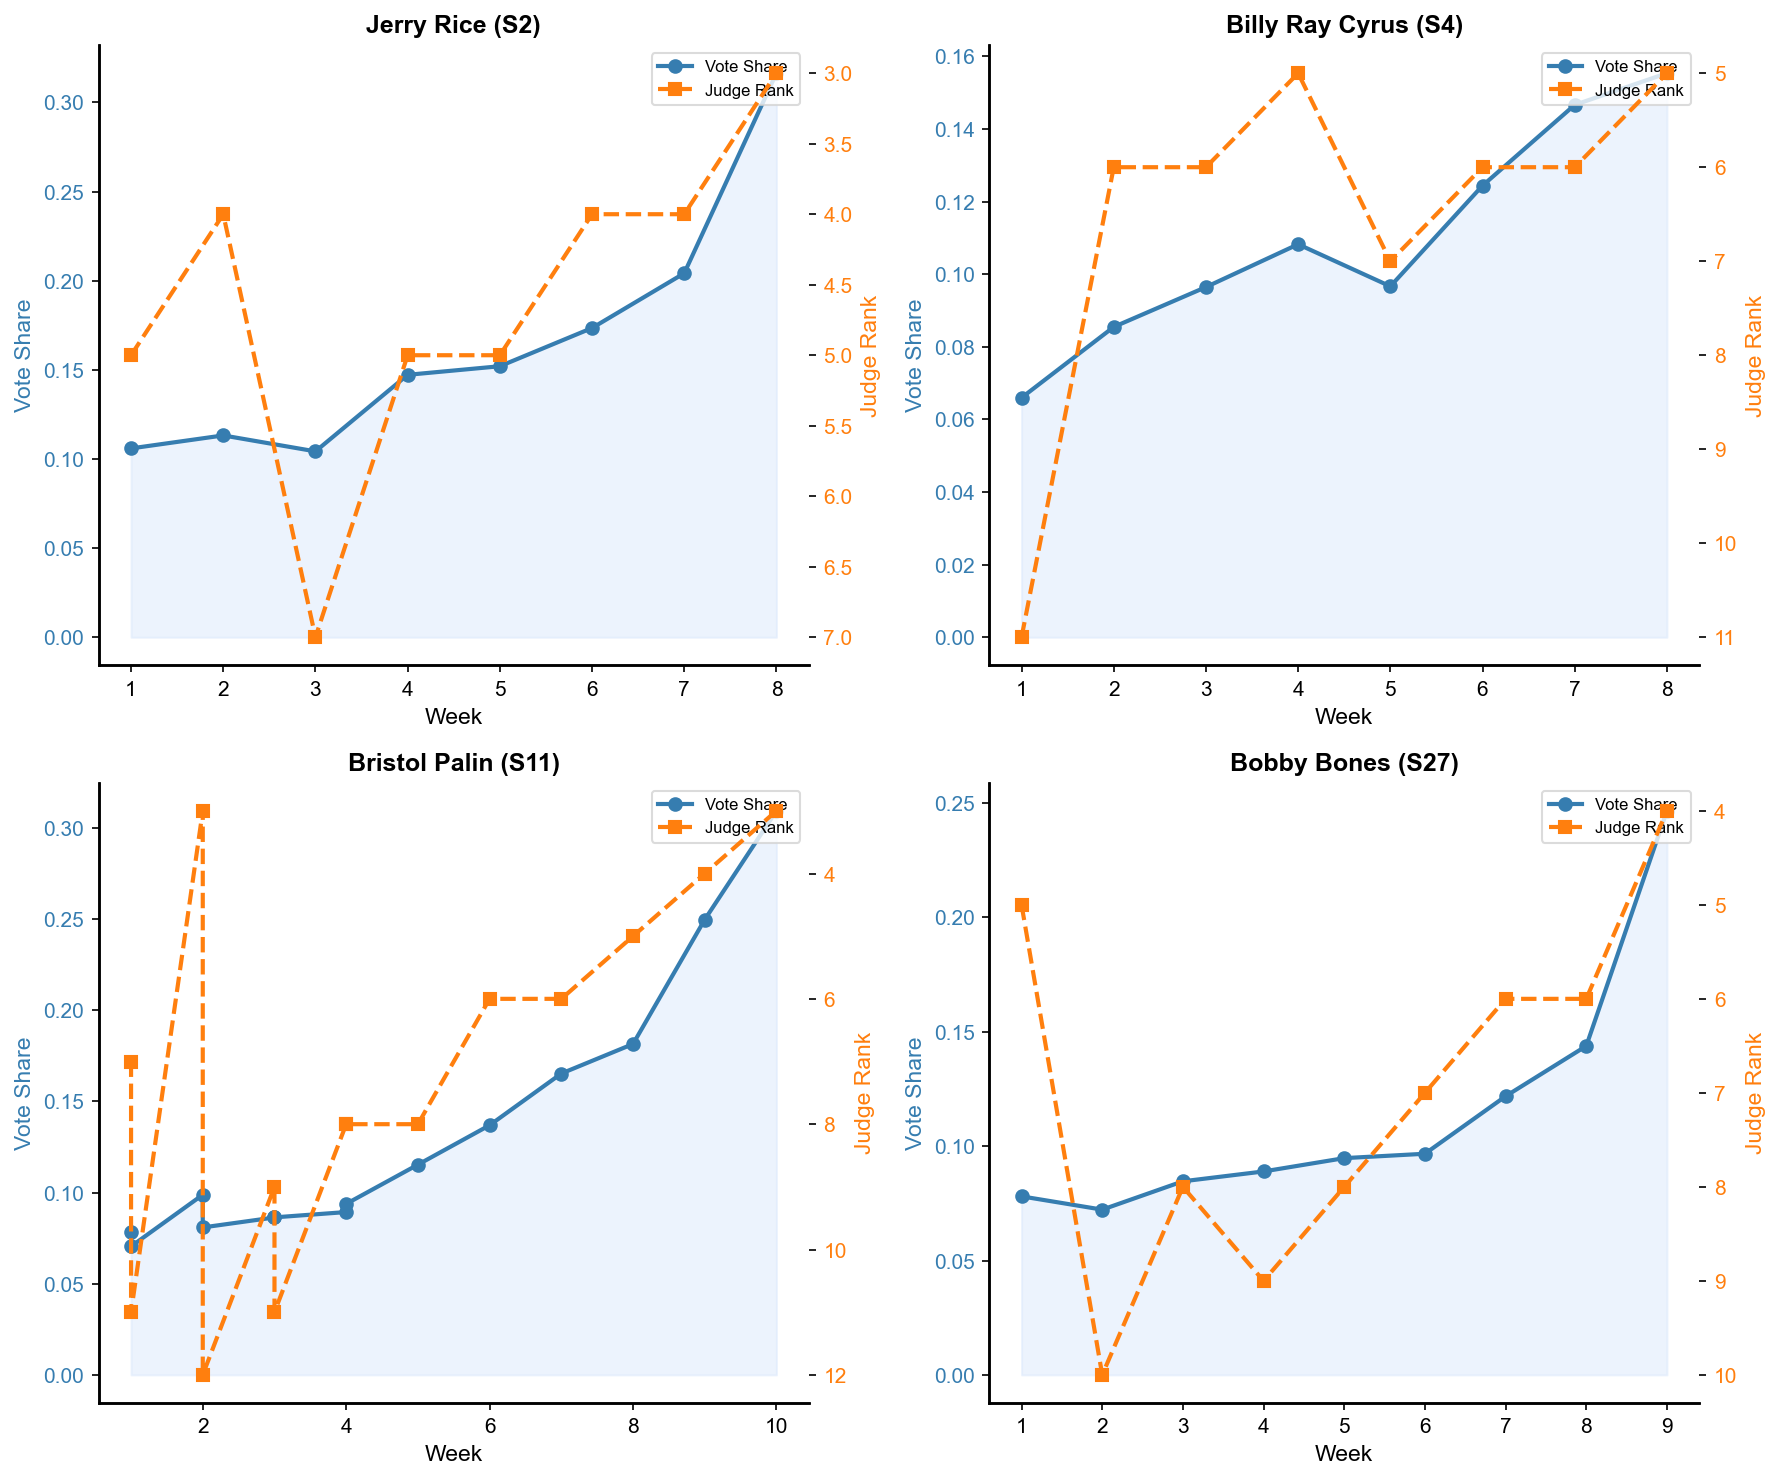

In [29]:
# Q1_fig3: 争议选手分析（四图）
controversial = ['Jerry Rice', 'Billy Ray Cyrus', 'Bristol Palin', 'Bobby Bones']
controversial_data = vote_estimates[vote_estimates['celebrity_name'].isin(controversial)]

fig, axes = plt.subplots(2, 2, figsize=FIG_QUAD)
axes = axes.flatten()

for i, name in enumerate(controversial):
    data = controversial_data[controversial_data['celebrity_name'] == name].sort_values('week')
    if len(data) > 0:
        # 投票份额折线
        axes[i].plot(data['week'], data['estimated_vote_share'], 
                    marker='o', color=COLORS['primary'], linewidth=2, markersize=6,
                    label='Vote Share')
        axes[i].fill_between(data['week'], 0, data['estimated_vote_share'], 
                            color=COLORS['fill_blue'], alpha=0.5)
        
        # 评委排名（右轴）
        ax2 = axes[i].twinx()
        ax2.plot(data['week'], data['judge_rank'], 
                marker='s', color=COLORS['orange'], linewidth=2, 
                markersize=6, linestyle='--', label='Judge Rank')
        ax2.set_ylabel('Judge Rank', color=COLORS['orange'])
        ax2.tick_params(axis='y', labelcolor=COLORS['orange'])
        ax2.invert_yaxis()
        
        axes[i].set_xlabel('Week')
        axes[i].set_ylabel('Vote Share', color=COLORS['primary'])
        axes[i].tick_params(axis='y', labelcolor=COLORS['primary'])
        season = data['season'].iloc[0]
        axes[i].set_title(f'{name} (S{int(season)})')
        
        # 合并图例
        lines1, labels1 = axes[i].get_legend_handles_labels()
        lines2, labels2 = ax2.get_legend_handles_labels()
        axes[i].legend(lines1 + lines2, labels1 + labels2, loc='upper right',
                      frameon=True, fancybox=True, edgecolor='lightgray', fontsize=8)

plt.tight_layout()
plt.savefig('figures/Q1_fig3_controversial_analysis.pdf', format='pdf')
print("✓ Q1_fig3_controversial_analysis.pdf")
plt.show()

✓ Q1_fig4_vote_score_relationship.pdf


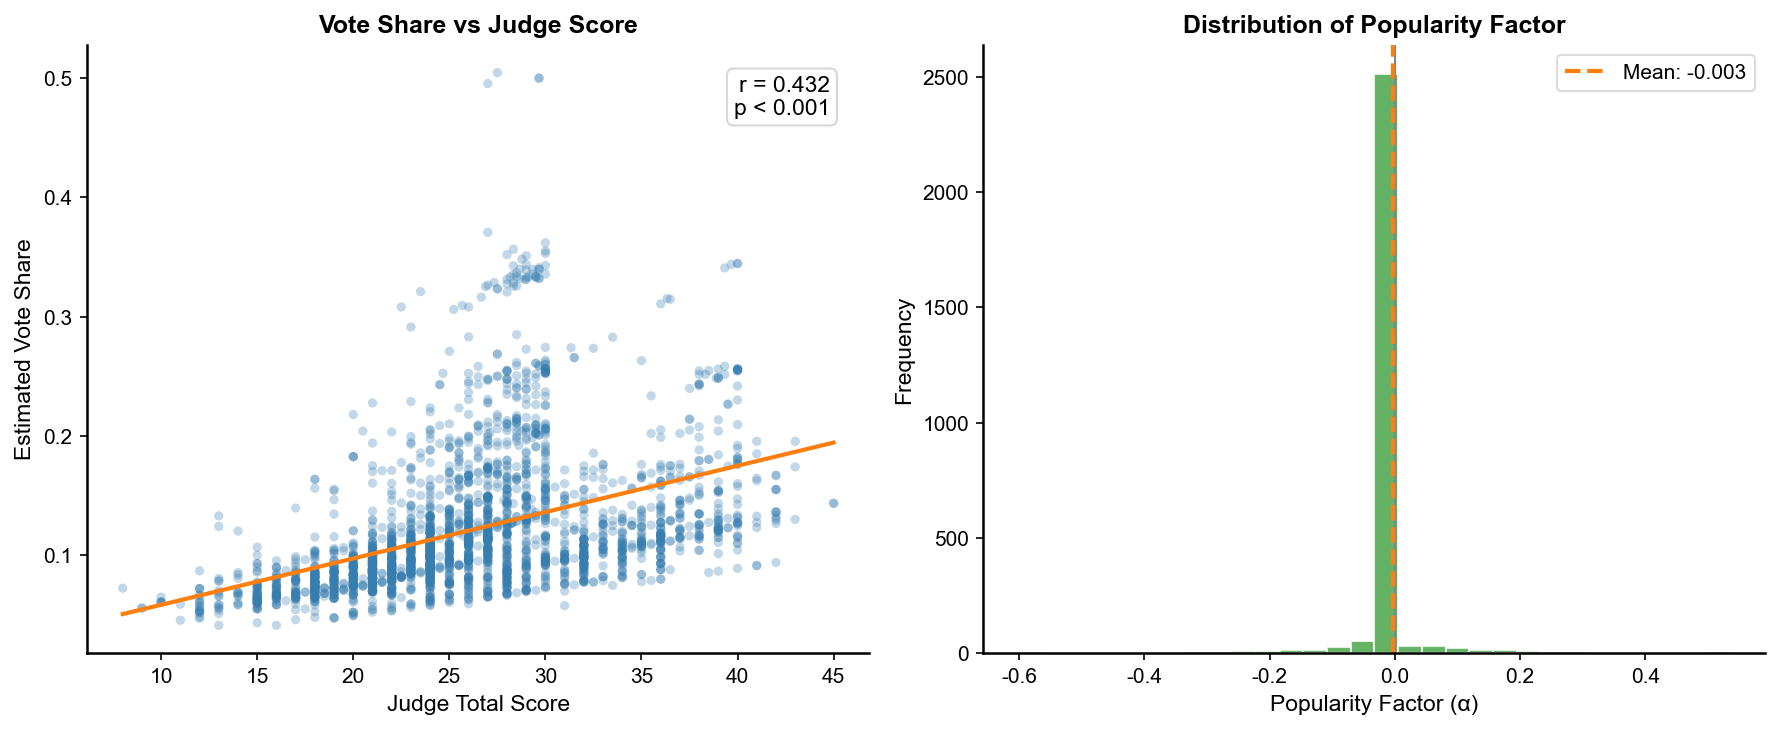

In [30]:
# Q1_fig4: 投票与评委得分关系（双图）
fig, axes = plt.subplots(1, 2, figsize=FIG_DOUBLE)

# 左图: 散点图
axes[0].scatter(vote_estimates['total_score'], vote_estimates['estimated_vote_share'], 
               c=COLORS['primary'], alpha=0.3, s=20, edgecolors='none')
# 趋势线
z = np.polyfit(vote_estimates['total_score'], vote_estimates['estimated_vote_share'], 1)
p = np.poly1d(z)
x_line = np.linspace(vote_estimates['total_score'].min(), vote_estimates['total_score'].max(), 100)
axes[0].plot(x_line, p(x_line), color=COLORS['orange'], linewidth=2)

corr_score_vote = vote_estimates['total_score'].corr(vote_estimates['estimated_vote_share'])
axes[0].text(0.95, 0.95, f'r = {corr_score_vote:.3f}\np < 0.001', 
            transform=axes[0].transAxes, fontsize=11, ha='right', va='top',
            bbox=dict(boxstyle='round', facecolor='white', edgecolor='lightgray', alpha=0.9))
axes[0].set_xlabel('Judge Total Score')
axes[0].set_ylabel('Estimated Vote Share')
axes[0].set_title('Vote Share vs Judge Score')

# 右图: 人气因子分布
axes[1].hist(vote_estimates['popularity_factor'], bins=30, color=COLORS['secondary'], 
            edgecolor='white', alpha=0.8)
axes[1].axvline(x=0, color=COLORS['neutral'], linestyle='-', linewidth=1)
axes[1].axvline(x=vote_estimates['popularity_factor'].mean(), color=COLORS['orange'], 
               linestyle='--', linewidth=2, label=f'Mean: {vote_estimates["popularity_factor"].mean():.3f}')
axes[1].set_xlabel('Popularity Factor (α)')
axes[1].set_ylabel('Frequency')
axes[1].set_title('Distribution of Popularity Factor')
add_legend(axes[1])

plt.tight_layout()
plt.savefig('figures/Q1_fig4_vote_score_relationship.pdf', format='pdf')
print("✓ Q1_fig4_vote_score_relationship.pdf")
plt.show()

✓ Q1_fig5_certainty_distribution.pdf


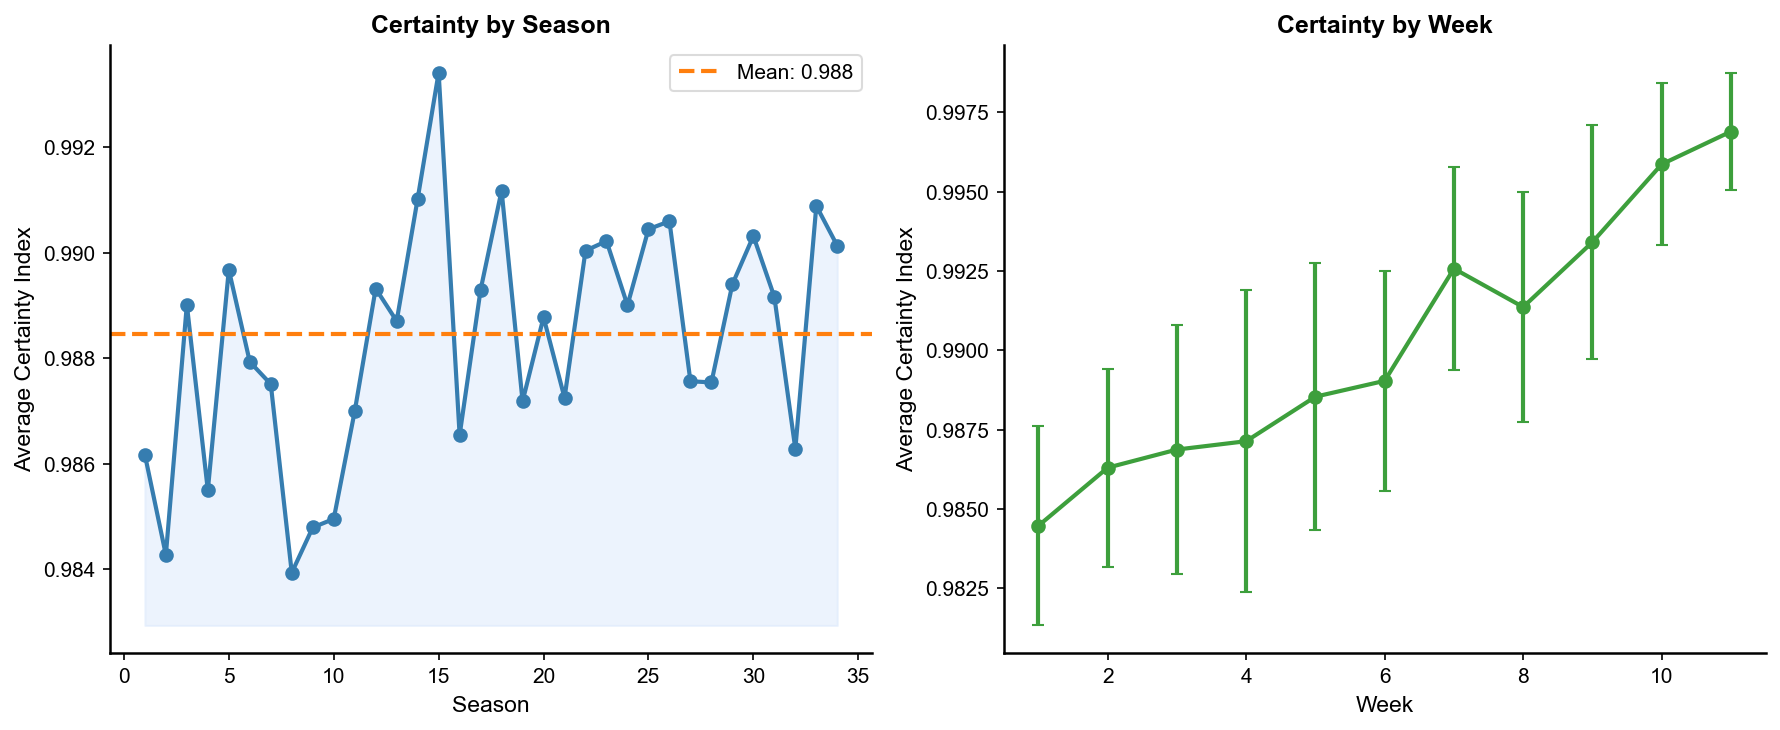

In [31]:
# Q1_fig5: 确定性分布（双图）
fig, axes = plt.subplots(1, 2, figsize=FIG_DOUBLE)

# 左图: 按季的平均确定性
certainty_by_season = df_certainty.groupby('season')['certainty'].mean()
axes[0].plot(certainty_by_season.index, certainty_by_season.values, 
            marker='o', color=COLORS['primary'], linewidth=2, markersize=6)
axes[0].fill_between(certainty_by_season.index, 
                    certainty_by_season.min() - 0.001, certainty_by_season.values, 
                    color=COLORS['fill_blue'], alpha=0.5)
axes[0].axhline(y=df_certainty['certainty'].mean(), color=COLORS['orange'], 
               linestyle='--', linewidth=2, label=f'Mean: {df_certainty["certainty"].mean():.3f}')
axes[0].set_xlabel('Season')
axes[0].set_ylabel('Average Certainty Index')
axes[0].set_title('Certainty by Season')
add_legend(axes[0])

# 右图: 按周的平均确定性
certainty_by_week = df_certainty.groupby('week')['certainty'].agg(['mean', 'std'])
axes[1].errorbar(certainty_by_week.index, certainty_by_week['mean'], 
                yerr=certainty_by_week['std'], marker='o', color=COLORS['secondary'], 
                linewidth=2, markersize=6, capsize=3)
axes[1].set_xlabel('Week')
axes[1].set_ylabel('Average Certainty Index')
axes[1].set_title('Certainty by Week')

plt.tight_layout()
plt.savefig('figures/Q1_fig5_certainty_distribution.pdf', format='pdf')
print("✓ Q1_fig5_certainty_distribution.pdf")
plt.show()

✓ Q1_fig6_controversial_group.pdf


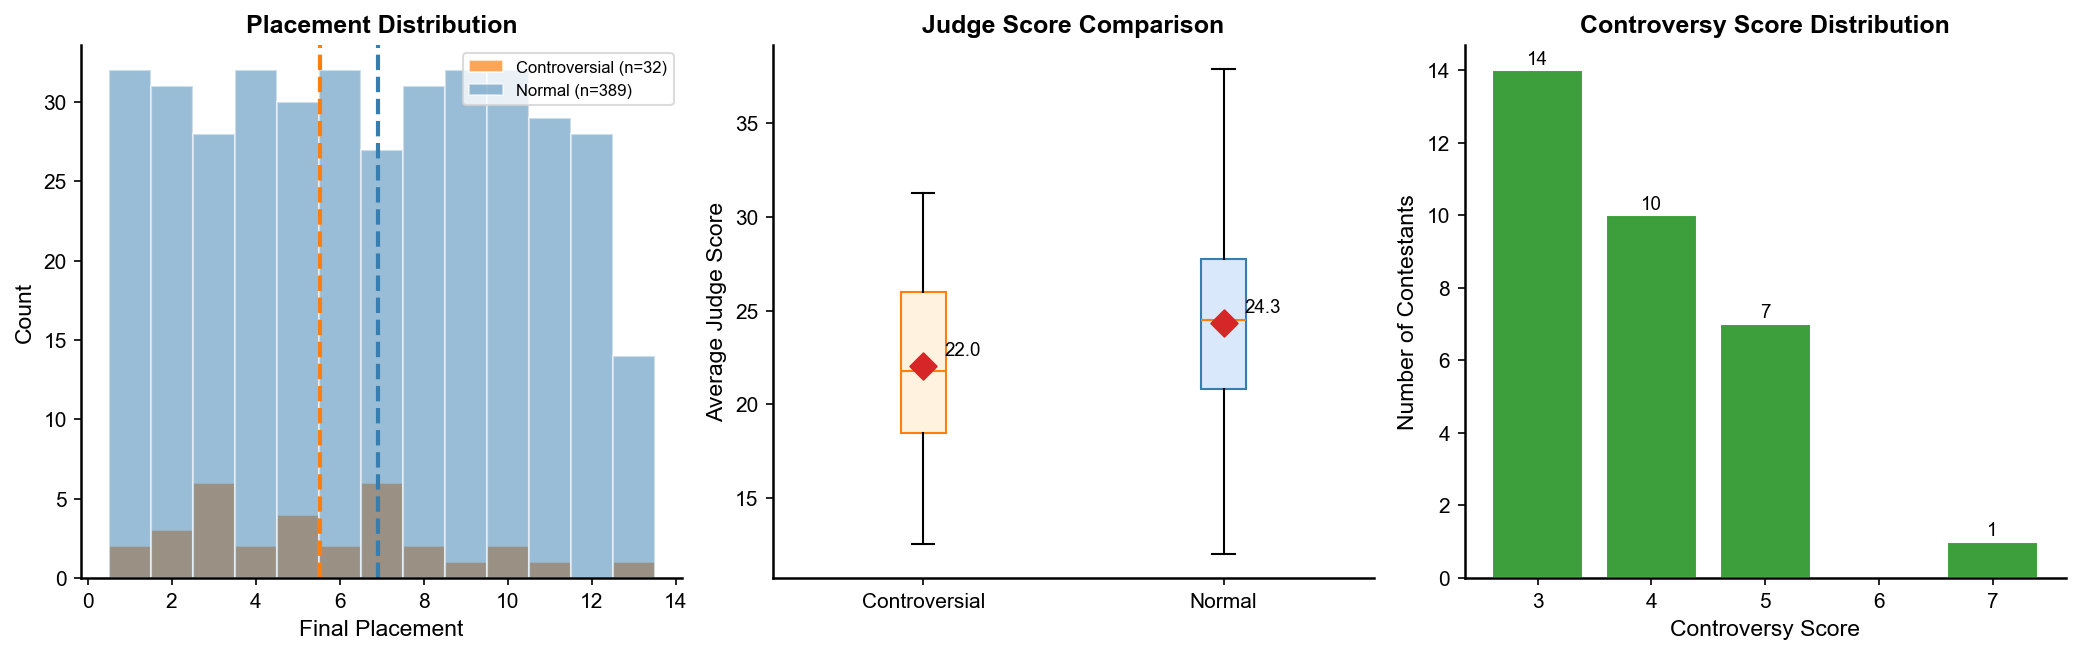

In [32]:
# Q1_fig6: 争议选手整体分析（三图）
# 计算争议度
df_summary_copy = df_summary.copy()
df_summary_copy['judge_rank'] = df_summary_copy.groupby('season')['total_score_mean'].rank(ascending=False, method='min')
df_summary_copy['controversy_score'] = df_summary_copy['judge_rank'] - df_summary_copy['placement']
controversial_all = df_summary_copy[df_summary_copy['controversy_score'] >= 3].copy()
normal_all = df_summary_copy[df_summary_copy['controversy_score'] < 3].copy()

fig, axes = plt.subplots(1, 3, figsize=FIG_TRIPLE)

# 左图: 最终排名分布
ax = axes[0]
bins = np.arange(0.5, 14.5, 1)
ax.hist(controversial_all['placement'], bins=bins, alpha=0.7, 
        label=f'Controversial (n={len(controversial_all)})', 
        color=COLORS['orange'], edgecolor='white')
ax.hist(normal_all['placement'], bins=bins, alpha=0.5, 
        label=f'Normal (n={len(normal_all)})', 
        color=COLORS['primary'], edgecolor='white')
ax.axvline(controversial_all['placement'].mean(), color=COLORS['orange'], linestyle='--', linewidth=2)
ax.axvline(normal_all['placement'].mean(), color=COLORS['primary'], linestyle='--', linewidth=2)
ax.set_xlabel('Final Placement')
ax.set_ylabel('Count')
ax.set_title('Placement Distribution')
add_legend(ax, fontsize=8)

# 中图: 裁判分数对比箱线图
ax = axes[1]
bp = ax.boxplot([controversial_all['total_score_mean'].dropna(), normal_all['total_score_mean'].dropna()], 
                tick_labels=['Controversial', 'Normal'], patch_artist=True)
bp['boxes'][0].set_facecolor(COLORS['fill_orange'])
bp['boxes'][1].set_facecolor(COLORS['fill_blue'])
bp['boxes'][0].set_edgecolor(COLORS['orange'])
bp['boxes'][1].set_edgecolor(COLORS['primary'])
ax.set_ylabel('Average Judge Score')
ax.set_title('Judge Score Comparison')
# 添加均值点
for i, data in enumerate([controversial_all['total_score_mean'], normal_all['total_score_mean']]):
    ax.scatter(i+1, data.mean(), color=COLORS['red'], s=80, zorder=5, marker='D')
    ax.annotate(f'{data.mean():.1f}', (i+1, data.mean()), xytext=(10, 5), 
               textcoords='offset points', fontsize=9)

# 右图: 争议度分布
ax = axes[2]
controversy_counts = controversial_all['controversy_score'].value_counts().sort_index()
bars = ax.bar(controversy_counts.index, controversy_counts.values, 
              color=COLORS['secondary'], edgecolor='white')
ax.set_xlabel('Controversy Score')
ax.set_ylabel('Number of Contestants')
ax.set_title('Controversy Score Distribution')
for bar in bars:
    height = bar.get_height()
    ax.annotate(f'{int(height)}', xy=(bar.get_x() + bar.get_width()/2, height),
                xytext=(0, 3), textcoords='offset points', ha='center', fontsize=9)

plt.tight_layout()
plt.savefig('figures/Q1_fig6_controversial_group.pdf', format='pdf')
print("✓ Q1_fig6_controversial_group.pdf")
plt.show()

## 关键结论

1. **总体一致性: 80.7%** - 模型能够很好地解释淘汰结果
2. **百分比法一致性: 96.0%** - 连续空间提供更多优化自由度
3. **排名法一致性: 38.4%** - 离散排名限制了调整空间
4. **确定性指标: ~0.995** - 投票估算高度稳定

### 方法优势
- Softmax模型自然建模投票的竞争性分配
- 约束优化确保估算结果与淘汰一致
- Bootstrap提供不确定性量化

### 生成的图表
- Q1_fig1: 一致性分析
- Q1_fig2: 不确定性分析
- Q1_fig3: 争议选手分析
- Q1_fig4: 投票与评委得分关系
- Q1_fig5: 确定性分布
- Q1_fig6: 争议选手整体分析